# food_4_portion_data ↔ RecipeNLG ingredient matching

Self-contained notebook for:

1. Loading 10K RecipeNLG recipes and parsing ingredient lines
2. Loading `usda.food_4_portion_data` (4 core macros + density-inferable portion, deduped) and parsing `description` with the **same schema**
3. Matching recipe ingredients → `fdc_id` via token blocking + weighted fuzzy scoring

Implementation: [`scripts/ingredient_match.py`](../scripts/ingredient_match.py), [`scripts/load_food_4_portion_data.py`](../scripts/load_food_4_portion_data.py), [`scripts/ingredient_normalize.py`](../scripts/ingredient_normalize.py)

Cached match outputs: `scratch/recipe_matching_10k/` (loaded automatically when present).

In [35]:
import ast
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

from food_name_prefixes import words_before_delimiters
from ingredient_match import match_ingredients_to_food
from ingredient_normalize import apply_ingredient_parse
from load_food_catalog import load_food_non_branded_matching
from load_food_4_portion_data import load_food_4_portion_data
from parse_recipe_ingredient import parse_ingredient_fields

# Import via alias so the `recipe_match_summary` DataFrame (§5) never shadows the module.
import importlib
import recipe_match_summary as recipe_match_metrics

importlib.reload(recipe_match_metrics)

summarize_recipe_matches = recipe_match_metrics.summarize_recipe_matches
compare_ingredient_match_runs = recipe_match_metrics.compare_ingredient_match_runs
compare_match_summaries = recipe_match_metrics.compare_match_summaries
ingredient_match_comparison = recipe_match_metrics.ingredient_match_comparison
recipes_all_but_one_resolved_either_catalog = (
    recipe_match_metrics.recipes_all_but_one_resolved_either_catalog
)

from match_review import (
    REVIEW_COLUMNS,
    filter_matches,
    load_matches_csv,
    review_matches,
    summarize_match_qualities,
)

from recipe_match_cache import (
    DEFAULT_CACHE_DIR,
    INGREDIENT_MATCHES_F4,
    INGREDIENT_MATCHES_FULL,
    RECIPE_MATCH_COMPARISON,
    RECIPE_SUMMARY_F4,
    RECIPE_SUMMARY_FULL,
    load_or_run_ingredient_matches,
    load_or_run_summary,
    migrate_legacy_scratch_csvs,
    write_manifest,
)

MATCH_CACHE_DIR = DEFAULT_CACHE_DIR
MATCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_migrated = migrate_legacy_scratch_csvs(MATCH_CACHE_DIR)
if _migrated:
    print(f"Migrated legacy CSVs → {MATCH_CACHE_DIR}: {', '.join(_migrated)}")


## 1. Recipe ingredients (10K recipes)

In [2]:
RECIPE_NLG_PATH = ROOT / "Data/recipes/RecipeNLG.csv"
RECIPE_NROWS = 10_000


def parse_ingredient_list(value) -> list[str]:
    """RecipeNLG pseudo-JSON ingredient array → list of strings."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    text = str(value).strip()
    if not text or text == "[]":
        return []
    if text.startswith("["):
        text = text[1:]
    if text.endswith("]"):
        text = text[:-1]
    text = text.strip()
    if not text:
        return []
    if '", "' not in text:
        item = text.strip('"')
        return [item] if item else []
    parts = text.split('", "')
    out: list[str] = []
    for i, part in enumerate(parts):
        part = part.strip()
        if i == 0:
            part = part.removeprefix('["').removeprefix('"')
        if i == len(parts) - 1:
            part = part.removesuffix('"]').removesuffix('"')
        if part:
            out.append(part)
    return out


def parse_ner_list(value) -> list[str]:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else []
    except (SyntaxError, ValueError):
        return []


def _as_text(value) -> str | None:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    text = str(value).strip()
    if not text or text.casefold() == "nan":
        return None
    return text


recipes = pd.read_csv(RECIPE_NLG_PATH, nrows=RECIPE_NROWS)
recipes = recipes.rename(columns={"Unnamed: 0": "recipe_id"})
recipes["ingredients_list"] = recipes["ingredients"].map(parse_ingredient_list)
recipes["ner_list"] = recipes["NER"].map(parse_ner_list)

print(f"recipes: {len(recipes):,}")

recipes: 10,000


In [3]:
recipe_ingredients = (
    recipes[["recipe_id", "ingredients_list"]]
    .explode("ingredients_list")
    .rename(columns={"ingredients_list": "ingredient"})
    .reset_index(drop=True)
)

parsed = recipe_ingredients["ingredient"].map(parse_ingredient_fields)
recipe_ingredients = pd.concat(
    [recipe_ingredients, pd.DataFrame(parsed.tolist())],
    axis=1,
)
recipe_ingredients["ingredient_idx"] = recipe_ingredients.groupby("recipe_id").cumcount()

print(f"ingredient rows: {len(recipe_ingredients):,}")
print(recipe_ingredients["parse_status"].value_counts())
recipe_ingredients.head(8)

ingredient rows: 74,991
parse_status
ok           71049
no_amount     3916
ambiguous       26
Name: count, dtype: int64


,recipe_id,ingredient,quantity,quantity_max,unit,unit_raw,amount_text,name,size,preparation,parse_status,parse_method,ingredient_idx
0,0,1 c. firmly packed brown sugar,1.0,1.0,c,1 c,1 c,brown sugar,NaN,NaN,ok,ingredient_parser,0
1,0,1/2 c. evaporated milk,0.5,0.5,c,1/2 c,1/2 c,evaporated milk,NaN,NaN,ok,ingredient_parser,1
2,0,1/2 tsp. vanilla,0.5,0.5,tsps,1/2 tsps,1/2 tsps,vanilla,NaN,NaN,ok,ingredient_parser,2
3,0,1/2 c. broken nuts (pecans),0.5,0.5,c,1/2 c,1/2 c,broken nuts (pecans),NaN,NaN,ok,ingredient_parser,3
4,0,2 Tbsp. butter or margarine,2.0,2.0,Tbsps,2 Tbsps,2 Tbsps,"butter, margarine",NaN,NaN,ok,ingredient_parser,4
5,0,3 1/2 c. bite size shredded rice biscuits,3.5,3.5,c,3 1/2 c,3 1/2 c,rice biscuits,NaN,bite size shredded,ok,ingredient_parser,5
6,1,"1 small jar chipped beef, cut up",1.0,1.0,jar,1 jar,"1 jar, 1 small",beef,NaN,"chipped, cut up",ok,ingredient_parser,0
7,1,4 boned chicken breasts,4.0,4.0,NaN,4,4,chicken breasts,NaN,boned,ok,ingredient_parser,1


## 2. Normalize `food_4_portion_data` (same parsing schema)

In [4]:
# Cached at scratch/food_4_portion_data.csv after first DB load
food_f4_raw = load_food_4_portion_data()
food_f4_raw["ingredient"] = food_f4_raw["description"]

print(f"food_4_portion_data rows: {len(food_f4_raw):,}")
food_f4_raw.head(3)

food_mvp rows: 7,700


,fdc_id,data_type,description,food_category_id,publication_date,ingredient
0,167549,sr_legacy_food,"Snacks, popcorn, oil-popped, microwave, regula...",23,2019-04-01,"Snacks, popcorn, oil-popped, microwave, regula..."
1,167551,sr_legacy_food,"Snacks, popcorn, caramel-coated, with peanuts",23,2019-04-01,"Snacks, popcorn, caramel-coated, with peanuts"
2,167561,sr_legacy_food,"Snacks, trail mix, regular",23,2019-04-01,"Snacks, trail mix, regular"


In [5]:
food_f4_ingredients = apply_ingredient_parse(food_f4_raw, text_col="ingredient")
food_f4_ingredients["prefix"] = food_f4_ingredients["description"].map(
    words_before_delimiters
)

print("food_4_portion_data parse status:")
print(food_f4_ingredients["parse_status"].value_counts())
food_f4_ingredients[
    [
        "fdc_id",
        "data_type",
        "description",
        "prefix",
        "name",
        "size",
        "preparation",
        "parse_status",
        "parse_method",
    ]
].head(8)

food_mvp parse status:
parse_status
no_amount    7671
ok             28
ambiguous       1
Name: count, dtype: int64


,fdc_id,data_type,description,prefix,name,size,preparation,parse_status,parse_method
0,167549,sr_legacy_food,"Snacks, popcorn, oil-popped, microwave, regula...",Snacks,"Snacks, popcorn",NaN,oil-popped,no_amount,ingredient_parser
1,167551,sr_legacy_food,"Snacks, popcorn, caramel-coated, with peanuts",Snacks,"Snacks, popcorn",NaN,caramel-coated,no_amount,ingredient_parser
2,167561,sr_legacy_food,"Snacks, trail mix, regular",Snacks,"Snacks, trail mix",NaN,NaN,no_amount,ingredient_parser
3,167565,sr_legacy_food,"Candies, NESTLE, BUTTERFINGER Bar",Candies,"Candies, NESTLE, BUTTERFINGER Bars",NaN,NaN,no_amount,ingredient_parser
4,167568,sr_legacy_food,"Baking chocolate, unsweetened, squares",Baking chocolate,Baking chocolate,NaN,squares,no_amount,ingredient_parser
5,167569,sr_legacy_food,"Candies, confectioner's coating, yogurt",Candies,"Candies, confectioner's coating, yogurt",NaN,NaN,no_amount,ingredient_parser
6,167570,sr_legacy_food,"Candies, confectioner's coating, peanut butter",Candies,"Candies, confectioner's coating, peanut butter",NaN,NaN,no_amount,ingredient_parser
7,167571,sr_legacy_food,"Candies, white chocolate",Candies,"Candies, white chocolate",NaN,NaN,no_amount,ingredient_parser


## 3. Match recipe ingredients → `fdc_id`

Uses token-index blocking + weighted features (`token_recall`, `token_precision`, `fuzzy_score`, `exact_hit`, size/prep). Outputs `match_stage`, `match_quality`, and `match_quality_score`.

In [6]:
assert "recipe_ingredients" in globals(), "Run §1–2 first"

_n_ing = len(recipe_ingredients)
MATCHES_F4_PATH = MATCH_CACHE_DIR / INGREDIENT_MATCHES_F4
write_manifest(
    MATCH_CACHE_DIR,
    recipe_nrows=RECIPE_NROWS,
    n_ingredient_rows=_n_ing,
)

ingredient_matches = load_or_run_ingredient_matches(
    MATCHES_F4_PATH,
    lambda: match_ingredients_to_food(
        recipe_ingredients,
        food_f4_ingredients,
        show_progress=True,
    ),
    expected_rows=_n_ing,
    cache_key="ingredient_matches_f4",
    dir_path=MATCH_CACHE_DIR,
)

print(f"rows: {len(ingredient_matches):,}")
ingredient_matches[
    [
        "recipe_id",
        "ingredient",
        "name",
        "matched_fdc_id",
        "matched_description",
        "match_stage",
        "match_score",
        "match_margin",
        "match_quality",
        "token_recall",
        "fuzzy_score",
    ]
].head(10)

Matching: 100%|██████████| 74991/74991 [00:34<00:00, 2188.92it/s]


rows: 74,991


,recipe_id,ingredient,name,matched_fdc_id,matched_description,match_stage,match_score,match_margin,match_quality,token_recall,fuzzy_score
0,0,1 c. firmly packed brown sugar,brown sugar,2710260.0,"Sugar, brown",exact,0.910870,0.200870,high,1.000000,0.869565
1,0,1/2 c. evaporated milk,evaporated milk,2705399.0,"Milk, evaporated, whole",exact,0.789474,0.091974,high,1.000000,0.631579
2,0,1/2 tsp. vanilla,vanilla,167575.0,"Ice creams, vanilla",exact,0.850000,0.012500,medium,1.000000,1.000000
3,0,1/2 c. broken nuts (pecans),broken nuts (pecans),170182.0,"Nuts, pecans",exact,0.645833,0.092500,medium,0.666667,0.375000
4,0,2 Tbsp. butter or margarine,"butter, margarine",172339.0,"Margarine-like, margarine-butter blend, soybea...",exact,0.727778,0.007143,medium,1.000000,0.592593
5,0,3 1/2 c. bite size shredded rice biscuits,rice biscuits,174902.0,"Biscuits, plain or buttermilk, dry mix",exact,0.455000,0.088889,low,0.500000,0.666667
6,1,"1 small jar chipped beef, cut up",beef,168118.0,"Beef, bologna, reduced sodium",exact,1.000000,1.000000,high,1.000000,1.000000
7,1,4 boned chicken breasts,chicken breasts,2707468.0,"Chicken, meatless, NFS",exact,0.538636,0.000000,low,0.500000,0.545455
8,1,1 can cream of mushroom soup,cream of mushroom soup,2710107.0,"Soup, cream of mushroom",exact,0.930000,0.060000,medium,1.000000,0.933333
9,1,1 carton sour cream,sour cream,170869.0,"Sour cream, imitation, cultured",exact,1.000000,1.000000,high,1.000000,1.000000


## 4. Summary & quality

In [7]:
total = len(ingredient_matches)
resolved = ingredient_matches["matched_fdc_id"].notna().sum()

summary = pd.Series(
    {
        "ingredient_rows": total,
        "with_matched_fdc_id": resolved,
        "match_rate_pct": round(100 * resolved / total, 2),
        "high_quality": (ingredient_matches["match_quality"] == "high").sum(),
        "medium_quality": (ingredient_matches["match_quality"] == "medium").sum(),
        "low_quality": (ingredient_matches["match_quality"] == "low").sum(),
        "unresolved": (ingredient_matches["match_quality"] == "unresolved").sum(),
        "avg_match_score": round(ingredient_matches["match_score"].mean(), 4),
        "median_match_score": round(ingredient_matches["match_score"].median(), 4),
    }
)
print("Overall")
display(summary.to_frame("value"))

print("\nBy match_stage")
display(ingredient_matches["match_stage"].value_counts().to_frame("count"))

print("\nBy match_quality")
display(ingredient_matches["match_quality"].value_counts().to_frame("count"))

Overall


,value
ingredient_rows,74991.0000
with_matched_fdc_id,73749.0000
match_rate_pct,98.3400
high_quality,38947.0000
medium_quality,23418.0000
low_quality,7668.0000
unresolved,4958.0000
avg_match_score,0.8035
median_match_score,0.8750



By match_stage


,count
match_stage,
exact,63880
token_fuzzy,6153
unresolved,4958



By match_quality


,count
match_quality,
high,38947
medium,23418
low,7668
unresolved,4958


In [8]:
# Optional: NER agreement where recipe ingredient count == NER count
recipes["n_ingredients"] = recipes["ingredients_list"].str.len()
recipes["n_ner"] = recipes["ner_list"].str.len()
aligned_ids = set(
    recipes.loc[recipes["n_ingredients"] == recipes["n_ner"], "recipe_id"]
)
ner_by_recipe = recipes.set_index("recipe_id")["ner_list"].to_dict()

ingredient_matches["ner_label"] = [
    ner_by_recipe.get(rid, [None] * (idx + 1))[idx]
    if rid in aligned_ids
    else None
    for rid, idx in zip(
        ingredient_matches["recipe_id"],
        ingredient_matches["ingredient_idx"],
        strict=True,
    )
]


def ner_matches_parsed(name, ner) -> bool | None:
    n, e = _as_text(name), _as_text(ner)
    if n is None or e is None:
        return None
    return n == e or e in n or n in e


ingredient_matches["ner_match"] = [
    ner_matches_parsed(n, ner)
    for n, ner in zip(ingredient_matches["name"], ingredient_matches["ner_label"], strict=True)
]

aligned = (
    ingredient_matches["ner_label"].apply(_as_text).notna()
    & ingredient_matches["name"].apply(_as_text).notna()
)
with_fdc = aligned & ingredient_matches["matched_fdc_id"].notna()
ner_and_fdc = with_fdc & ingredient_matches["ner_match"].eq(True)

print(f"Recipes with aligned ingredient/NER lists: {len(aligned_ids):,}")
print(f"Aligned rows with fdc_id: {with_fdc.sum():,} ({100*with_fdc.sum()/aligned.sum():.1f}% of aligned)")
print(
    f"NER substring match among fdc-matched aligned: {ner_and_fdc.sum():,} "
    f"({100*ner_and_fdc.sum()/with_fdc.sum():.1f}%)"
)

Recipes with aligned ingredient/NER lists: 8,559
Aligned rows with fdc_id: 63,386 (98.6% of aligned)
NER substring match among fdc-matched aligned: 63,020 (99.4%)


In [9]:
print("Sample high-quality matches")
ingredient_matches.loc[ingredient_matches["match_quality"] == "high"].sample(
    8, random_state=1
)[[
    "ingredient",
    "name",
    "matched_description",
    "match_stage",
    "match_score",
    "match_margin",
    "token_recall",
    "fuzzy_score",
]]

print("\nSample low / unresolved")
low = ingredient_matches.loc[
    ingredient_matches["match_quality"].isin(["low", "unresolved"])
]
if len(low):
    low.sample(min(8, len(low)), random_state=2)[[
        "ingredient",
        "name",
        "match_query",
        "matched_description",
        "match_stage",
        "match_score",
        "match_margin",
        "n_candidates",
    ]]

Sample high-quality matches

Sample low / unresolved


In [10]:
# Matches persisted under MATCH_CACHE_DIR by §3 (ingredient_matches_f4.csv)
print(f"Cache: {MATCH_CACHE_DIR / INGREDIENT_MATCHES_F4}")

Saved → /Users/danielcosta/Berkeley/Capstone/scratch/ingredient_matches_10k.csv


## 5. Per-recipe match quality (10K recipes) — `food_4_portion_data`

One row per `recipe_id` with the share of ingredient lines in each `match_quality` tier and the mean `match_score`. **`percent_unmatched`** is the share with `match_quality == "unresolved"`. **`percent_med_high`** = `percent_high` + `percent_medium`. **`percent_high_100`** is 100 when every ingredient is high quality, else 0.

Requires `ingredient_matches` and `recipes` from earlier sections.


In [11]:
assert "ingredient_matches" in globals(), "Run §3 (matching) first"
assert "recipes" in globals(), "Run §1 first"

SUMMARY_F4_PATH = MATCH_CACHE_DIR / RECIPE_SUMMARY_F4

recipe_match_summary = load_or_run_summary(
    SUMMARY_F4_PATH,
    lambda: summarize_recipe_matches(ingredient_matches, recipes),
    expected_recipes=RECIPE_NROWS,
)

print(f"recipes in summary: {len(recipe_match_summary):,}")
recipe_match_summary.head(10)

recipes in summary: 10,000


,recipe_id,n_ingredients,percent_high,percent_medium,percent_low,percent_unmatched,percent_med_high,percent_high_100,avg_match_score,high,medium,low,unresolved
0,0,6,33.33,50.00,16.67,0.00,83.33,0.0,0.7298,2,3,1,0
1,1,4,50.00,25.00,25.00,0.00,75.00,0.0,0.8672,2,1,1,0
2,2,6,66.67,33.33,0.00,0.00,100.00,0.0,0.9099,4,2,0,0
3,3,5,40.00,40.00,20.00,0.00,80.00,0.0,0.8095,2,2,1,0
4,4,5,60.00,20.00,20.00,0.00,80.00,0.0,0.8064,3,1,1,0
5,5,10,50.00,30.00,20.00,0.00,80.00,0.0,0.8224,5,3,2,0
6,6,10,70.00,30.00,0.00,0.00,100.00,0.0,0.9600,7,3,0,0
7,7,6,66.67,33.33,0.00,0.00,100.00,0.0,0.8985,4,2,0,0
8,8,7,57.14,28.57,0.00,14.29,85.71,0.0,0.8147,4,2,0,1
9,9,6,33.33,33.33,16.67,16.67,66.66,0.0,0.6957,2,2,1,1


In [12]:
print("Mean percent of ingredients per quality tier (recipes with ≥1 ingredient):")
with_ing = recipe_match_summary.loc[recipe_match_summary["n_ingredients"] > 0]
display(
    with_ing[
        [
            "percent_high",
            "percent_medium",
            "percent_low",
            "percent_unmatched",
            "percent_med_high",
            "percent_high_100",
        ]
    ]
    .mean()
    .round(2)
    .to_frame("mean_pct")
)

print(
    f"\nRecipes with every ingredient high (percent_high_100 = 100): "
    f"{(with_ing['percent_high_100'] > 0).sum():,}"
)

print("\nDistribution of recipe-level avg_match_score:")
display(with_ing["avg_match_score"].describe().to_frame("value"))

print("\nExample: all ingredients high quality")
display(
    with_ing.loc[with_ing["percent_high"] == 100.0]
    .head(8)[["recipe_id", "n_ingredients", "avg_match_score", "percent_med_high"]]
)

print("\nExample: no high-quality matches")
display(
    with_ing.loc[with_ing["percent_high"] == 0.0]
    .head(8)[
        [
            "recipe_id",
            "n_ingredients",
            "percent_medium",
            "percent_low",
            "percent_unmatched",
            "percent_med_high",
            "avg_match_score",
        ]
    ]
)


Mean percent of ingredients per quality tier (recipes with ≥1 ingredient):


,mean_pct
percent_high,50.39
percent_medium,31.47
percent_low,10.83
percent_unmatched,7.31
percent_med_high,81.86
percent_high_100,1.15



Recipes with every ingredient high (percent_high_100 = 100): 115

Distribution of recipe-level avg_match_score:


,value
count,10000.000000
mean,0.794255
std,0.107959
min,0.000000
25%,0.733300
50%,0.808300
75%,0.872125
max,1.000000



Example: all ingredients high quality


,recipe_id,n_ingredients,avg_match_score,percent_med_high
62,62,2,1.0000,100.0
72,72,2,0.9300,100.0
129,129,5,0.9842,100.0
219,219,3,0.9403,100.0
297,297,4,1.0000,100.0
307,307,5,1.0000,100.0
393,393,8,0.9662,100.0
440,440,5,0.9239,100.0



Example: no high-quality matches


,recipe_id,n_ingredients,percent_medium,percent_low,percent_unmatched,percent_med_high,avg_match_score
12,12,3,100.00,0.00,0.00,100.00,0.7046
16,16,3,66.67,33.33,0.00,66.67,0.6139
37,37,3,33.33,33.33,33.33,33.33,0.5211
38,38,4,50.00,50.00,0.00,50.00,0.5872
121,121,7,71.43,28.57,0.00,71.43,0.6960
123,123,4,25.00,50.00,25.00,25.00,0.4690
174,174,3,66.67,0.00,33.33,66.67,0.7036
236,236,6,33.33,33.33,33.33,33.33,0.4868


In [13]:
print(f"Cache: {MATCH_CACHE_DIR / RECIPE_SUMMARY_F4}")

Saved → /Users/danielcosta/Berkeley/Capstone/scratch/recipe_match_summary_10k.csv


## 6. Full non-branded food catalog (~101K foods)

Same 10K recipes and matcher, but candidates come from **all non-branded USDA `food` rows** (not only `food_4_portion_data`). Catalog rows use the USDA `description` as the match name (already a normalized title); recipe lines are still parsed as in §3.

First run matches ~75K ingredient lines against ~101K foods (~5–15 min). Results cache under `scratch/recipe_matching_10k/`; delete `ingredient_matches_full.csv` to re-run.

In [14]:
assert "recipe_ingredients" in globals(), "Run §1 first"

MATCHES_FULL_PATH = MATCH_CACHE_DIR / INGREDIENT_MATCHES_FULL
SUMMARY_FULL_PATH = MATCH_CACHE_DIR / RECIPE_SUMMARY_FULL
_n_ing = len(recipe_ingredients)

food_full = load_food_non_branded_matching()
print(f"Full catalog: {len(food_full):,} non-branded foods")


def _run_full_match():
    return match_ingredients_to_food(
        recipe_ingredients,
        food_full,
        show_progress=True,
        max_candidates=50,
    )


ingredient_matches_full = load_or_run_ingredient_matches(
    MATCHES_FULL_PATH,
    _run_full_match,
    expected_rows=_n_ing,
    cache_key="ingredient_matches_full",
    dir_path=MATCH_CACHE_DIR,
)

recipe_match_summary_full = load_or_run_summary(
    SUMMARY_FULL_PATH,
    lambda: summarize_recipe_matches(ingredient_matches_full, recipes),
    expected_recipes=RECIPE_NROWS,
)
print(f"recipes in full summary: {len(recipe_match_summary_full):,}")
recipe_match_summary_full.head(10)

Full catalog: 101,329 non-branded foods


Matching: 100%|██████████| 74991/74991 [14:37<00:00, 85.45it/s]   


recipes in full summary: 10,000


,recipe_id,n_ingredients,percent_high,percent_medium,percent_low,percent_unmatched,percent_med_high,percent_high_100,avg_match_score,high,medium,low,unresolved
0,0,6,16.67,83.33,0.00,0.00,100.00,0.0,0.7439,1,5,0,0
1,1,4,75.00,25.00,0.00,0.00,100.00,0.0,0.8918,3,1,0,0
2,2,6,66.67,33.33,0.00,0.00,100.00,0.0,0.8969,4,2,0,0
3,3,5,60.00,40.00,0.00,0.00,100.00,0.0,0.8357,3,2,0,0
4,4,5,40.00,40.00,20.00,0.00,80.00,0.0,0.8293,2,2,1,0
5,5,10,70.00,20.00,10.00,0.00,90.00,0.0,0.8926,7,2,1,0
6,6,10,80.00,20.00,0.00,0.00,100.00,0.0,0.9725,8,2,0,0
7,7,6,66.67,33.33,0.00,0.00,100.00,0.0,0.8829,4,2,0,0
8,8,7,57.14,28.57,0.00,14.29,85.71,0.0,0.8114,4,2,0,1
9,9,6,33.33,16.67,16.67,33.33,50.00,0.0,0.6887,2,1,1,2


In [15]:
print("Mean recipe-level metrics — full catalog (recipes with ≥1 ingredient):")
with_ing_full = recipe_match_summary_full.loc[recipe_match_summary_full["n_ingredients"] > 0]
display(
    with_ing_full[
        [
            "percent_high",
            "percent_medium",
            "percent_low",
            "percent_unmatched",
            "percent_med_high",
            "percent_high_100",
            "avg_match_score",
        ]
    ]
    .mean()
    .round(2)
    .to_frame("mean_pct_full")
)

print(
    f"Recipes with percent_high_100 = 100: "
    f"{(with_ing_full['percent_high_100'] > 0).sum():,}"
)

# Ingredient-level quality mix
print("\nIngredient-level match_quality (full catalog):")
display(
    ingredient_matches_full["match_quality"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("pct")
)

Mean recipe-level metrics — full catalog (recipes with ≥1 ingredient):


,mean_pct_full
percent_high,53.60
percent_medium,28.95
percent_low,8.05
percent_unmatched,9.41
percent_med_high,82.55
percent_high_100,2.10
avg_match_score,0.81


Recipes with percent_high_100 = 100: 210

Ingredient-level match_quality (full catalog):


,pct
match_quality,
high,55.02
medium,28.74
unresolved,8.73
low,7.51


In [16]:
print(f"Cache: {MATCHES_FULL_PATH}")
print(f"Cache: {SUMMARY_FULL_PATH}")

Saved → /Users/danielcosta/Berkeley/Capstone/scratch/ingredient_matches_full_10k.csv
Saved → /Users/danielcosta/Berkeley/Capstone/scratch/recipe_match_summary_full_10k.csv


## 7. Compare `food_4_portion_data` vs full catalog

Side-by-side recipe metrics and ingredient-level agreement when both runs resolve a match.

In [27]:
assert "recipe_match_summary" in globals(), "Run §5 first"
assert "recipe_match_summary_full" in globals(), "Run §6 first"

recipe_match_comparison = compare_match_summaries(
    recipe_match_summary, recipe_match_summary_full
)

metric_cols = [
    "percent_high",
    "percent_medium",
    "percent_low",
    "percent_unmatched",
    "percent_med_high",
    "percent_high_100",
    "avg_match_score",
]

with_ing_f4 = recipe_match_summary.loc[recipe_match_summary["n_ingredients"] > 0]
with_ing_full = recipe_match_summary_full.loc[recipe_match_summary_full["n_ingredients"] > 0]

comparison_table = pd.DataFrame(
    {
        "food_4_portion_data": with_ing_f4[metric_cols].mean().round(2),
        "full_catalog": with_ing_full[metric_cols].mean().round(2),
    }
)
comparison_table["delta_full_minus_f4"] = (
    comparison_table["full_catalog"] - comparison_table["food_4_portion_data"]
).round(2)

print("Mean recipe-level metrics (10K recipes with ≥1 ingredient):")
display(comparison_table)

ingredient_aggregate = compare_ingredient_match_runs(
    ingredient_matches, ingredient_matches_full
).rename(
    columns={
        "food_mvp": "food_4_portion_data",
        "delta_full_minus_mvp": "delta_full_minus_f4",
    }
)
print("\nIngredient-level aggregates (~75K lines; counts + tier %):")
display(ingredient_aggregate)

ingredient_cmp = ingredient_match_comparison(
    ingredient_matches, ingredient_matches_full
)
print("\nIngredient-level comparison (same recipe lines):")
display(pd.Series(ingredient_cmp, name="value"))

print("\nLargest gains in percent_high (full − food_4_portion_data):")
display(
    recipe_match_comparison.nlargest(8, "delta_percent_high")[
        [
            "recipe_id",
            "mvp_percent_high",
            "full_percent_high",
            "delta_percent_high",
            "mvp_avg_match_score",
            "full_avg_match_score",
        ]
    ]
)

COMPARISON_PATH = MATCH_CACHE_DIR / RECIPE_MATCH_COMPARISON
recipe_match_comparison.to_csv(COMPARISON_PATH, index=False)
print(f"\nSaved → {COMPARISON_PATH}")

Mean recipe-level metrics (10K recipes with ≥1 ingredient):


,food_mvp,full_catalog,delta_full_minus_mvp
percent_high,50.39,53.60,3.21
percent_medium,31.47,28.95,-2.52
percent_low,10.83,8.05,-2.78
percent_unmatched,7.31,9.41,2.10
percent_med_high,81.86,82.55,0.69
percent_high_100,1.15,2.10,0.95
avg_match_score,0.79,0.81,0.02



Ingredient-level aggregates (~75K lines; counts + tier %):


,food_mvp,full_catalog,delta_full_minus_mvp
n_ingredients,74991.0000,74991.0000,0.0000
high_count,38947.0000,41261.0000,2314.0000
high_pct,51.9400,55.0200,3.0800
medium_count,23418.0000,21552.0000,-1866.0000
medium_pct,31.2300,28.7400,-2.4900
low_count,7668.0000,5631.0000,-2037.0000
low_pct,10.2300,7.5100,-2.7200
unresolved_count,4958.0000,6547.0000,1589.0000
unresolved_pct,6.6100,8.7300,2.1200
avg_match_score,0.8035,0.8153,0.0118



Ingredient-level comparison (same recipe lines):


n_ingredients             74991.00
mvp_resolved_pct             98.34
full_resolved_pct            98.62
both_resolved_pct            98.34
same_fdc_when_both_pct       56.60
full_higher_score_pct        17.88
Name: value, dtype: float64


Largest gains in percent_high (full − mvp):


,recipe_id,mvp_percent_high,full_percent_high,delta_percent_high,mvp_avg_match_score,full_avg_match_score
12,12,0.00,66.67,66.67,0.7046,0.8946
1293,1293,0.00,66.67,66.67,0.7612,0.8153
2123,2123,0.00,66.67,66.67,0.7768,0.7660
9858,9858,0.00,66.67,66.67,0.7438,0.8421
4523,4523,0.00,60.00,60.00,0.5908,0.8828
469,469,25.00,75.00,50.00,0.7649,0.9053
1355,1355,33.33,83.33,50.00,0.8206,0.9750
1366,1366,50.00,100.00,50.00,0.8416,0.8416



Saved → /Users/danielcosta/Berkeley/Capstone/scratch/recipe_match_comparison_10k.csv


## 8. Visual comparison

Chart 2 includes a fourth threshold: recipes with **at most one** ingredient line that lacks a match in **either** `food_4_portion_data` or the full catalog (union across both runs).


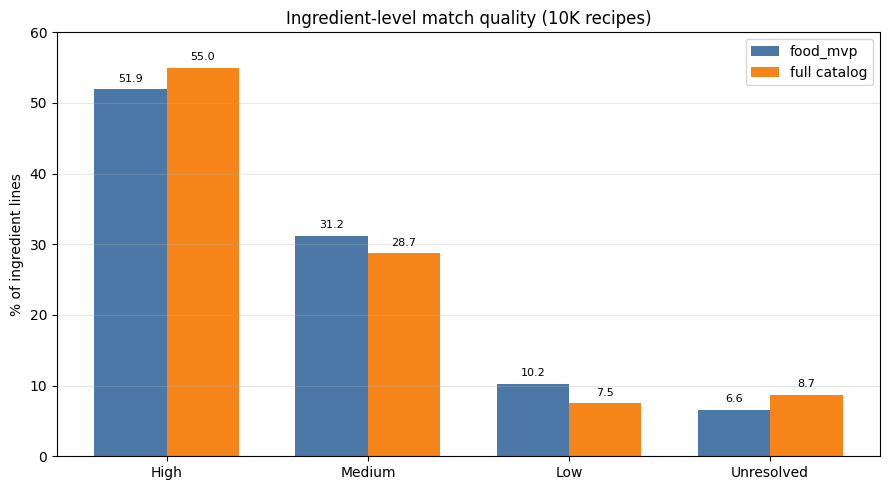

Recipes with ≤1 ingredient unresolved in either catalog: 9,944 (99.44% of recipes with ingredients)


,recipe_id,title,n_ingredients,n_resolved_either,n_unresolved_either,mvp_unresolved,full_unresolved
0,2595,Taco Pizza,45,45,0,4,5
1,7473,Polish Split Pea Soup(Do Not Stir This Soup),29,29,0,2,4
2,5655,Darlene'S Zucchini Relish,27,27,0,0,0
3,3864,Cincinnati-Style Chili,24,24,0,0,4
4,810,Meat Loaf,22,22,0,0,0
...,...,...,...,...,...,...,...
9939,7074,Bacon Pinwheel Appetizers,2,1,1,1,1
9940,8711,Kraut And Pineapple,2,1,1,1,2
9941,8935,Frozen Cucumbers,2,1,1,1,1
9942,9721,Jamie'S Famous Wienies And Cheese,2,1,1,1,1


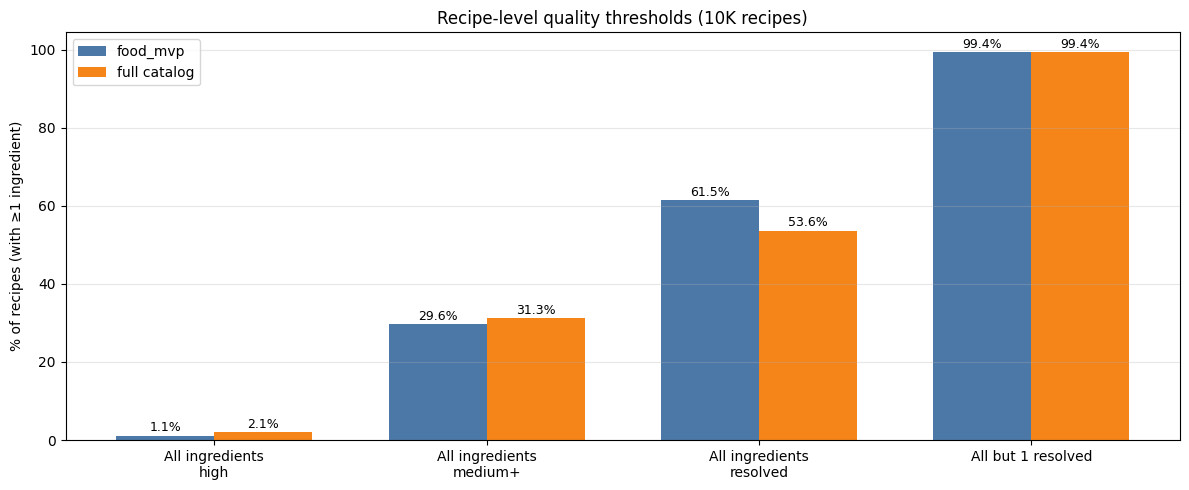

In [37]:
assert "ingredient_aggregate" in globals(), "Run §7 first"
assert "with_ing_f4" in globals() and "with_ing_full" in globals(), "Run §7 first"

# --- Chart 1: ingredient-line quality mix (pooled over ~75K lines) ---
tier_labels = ["High", "Medium", "Low", "Unresolved"]
tier_keys = ["high_pct", "medium_pct", "low_pct", "unresolved_pct"]
f4_ing_pct = [ingredient_aggregate.loc[k, "food_4_portion_data"] for k in tier_keys]
full_ing_pct = [ingredient_aggregate.loc[k, "full_catalog"] for k in tier_keys]

x = np.arange(len(tier_labels))
bar_w = 0.36

fig1, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(x - bar_w / 2, f4_ing_pct, bar_w, label="food_4_portion_data", color="#4C78A8")
ax1.bar(x + bar_w / 2, full_ing_pct, bar_w, label="full catalog", color="#F58518")
ax1.set_ylabel("% of ingredient lines")
ax1.set_title("Ingredient-level match quality (10K recipes)")
ax1.set_xticks(x, tier_labels)
ax1.set_ylim(0, 60)
ax1.legend()
ax1.grid(axis="y", alpha=0.3)
for i, (mv, fl) in enumerate(zip(f4_ing_pct, full_ing_pct)):
    ax1.text(i - bar_w / 2, mv + 0.8, f"{mv:.1f}", ha="center", va="bottom", fontsize=8)
    ax1.text(i + bar_w / 2, fl + 0.8, f"{fl:.1f}", ha="center", va="bottom", fontsize=8)
fig1.tight_layout()
plt.show()

# --- Chart 2: share of recipes meeting quality thresholds ---
def recipe_threshold_rates(summary: pd.DataFrame) -> dict[str, float]:
    with_ing = summary.loc[summary["n_ingredients"] > 0]
    n = len(with_ing)
    return {
        "All ingredients\nhigh": 100 * (with_ing["percent_high"] == 100).sum() / n,
        "All ingredients\nmedium+": 100 * (with_ing["percent_med_high"] == 100).sum() / n,
        "All ingredients\nresolved": 100 * (with_ing["unresolved"] == 0).sum() / n,
    }

f4_recipe_rates = recipe_threshold_rates(recipe_match_summary)
full_recipe_rates = recipe_threshold_rates(recipe_match_summary_full)

cross_rate, cross_detail = recipes_all_but_one_resolved_either_catalog(
    ingredient_matches, ingredient_matches_full, recipes
)
cross_detail = cross_detail.merge(
    recipe_match_summary[["recipe_id", "unresolved"]].rename(
        columns={"unresolved": "f4_unresolved"}
    ),
    on="recipe_id",
    how="left",
).merge(
    recipe_match_summary_full[["recipe_id", "unresolved"]].rename(
        columns={"unresolved": "full_unresolved"}
    ),
    on="recipe_id",
    how="left",
)

print(
    f"Recipes with ≤1 ingredient unresolved in either catalog: "
    f"{len(cross_detail):,} ({cross_rate:.2f}% of recipes with ingredients)"
)
display(
    cross_detail[
        [
            "recipe_id",
            "title",
            "n_ingredients",
            "n_resolved_either",
            "n_unresolved_either",
            "f4_unresolved",
            "full_unresolved",
        ]
    ]
)

recipe_labels = list(f4_recipe_rates.keys()) + [
    "All but 1 resolved"
]
f4_recipe_pct = [f4_recipe_rates[k] for k in f4_recipe_rates] + [cross_rate]
full_recipe_pct = [full_recipe_rates[k] for k in full_recipe_rates] + [cross_rate]

x2 = np.arange(len(recipe_labels))
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.bar(x2 - bar_w / 2, f4_recipe_pct, bar_w, label="food_4_portion_data", color="#4C78A8")
ax2.bar(x2 + bar_w / 2, full_recipe_pct, bar_w, label="full catalog", color="#F58518")
ax2.set_ylabel("% of recipes (with ≥1 ingredient)")
ax2.set_title("Recipe-level quality thresholds (10K recipes)")
ax2.set_xticks(x2, recipe_labels)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
for i, (mv, fl) in enumerate(zip(f4_recipe_pct, full_recipe_pct)):
    ax2.text(i - bar_w / 2, mv + 0.3, f"{mv:.1f}%", ha="center", va="bottom", fontsize=9)
    ax2.text(i + bar_w / 2, fl + 0.3, f"{fl:.1f}%", ha="center", va="bottom", fontsize=9)
fig2.tight_layout()
plt.show()

## 9. Match error analysis

Use `filter_matches()` / `review_matches()` to slice `ingredient_matches` by `match_quality`, score, margin, recipe, or text search. Works on in-memory results or `scratch/recipe_matching_10k/ingredient_matches_f4.csv` if §3 was not run this session.

**Quality tiers** (from `scripts/ingredient_match.py`): `high` (score ≥ 0.75 and margin ≥ 0.08), `medium`, `low`, `unresolved` (score < 0.40).


In [ ]:
if "ingredient_matches" not in globals():
    _fallback = MATCH_CACHE_DIR / INGREDIENT_MATCHES_F4
    ingredient_matches = load_matches_csv(_fallback)
    print(f"Loaded {len(ingredient_matches):,} rows from {_fallback}")

display(summarize_match_qualities(ingredient_matches))